In [ ]:
# ===========================================================
# PC-BKT (EP) : Personalized Clustered Bayesian Knowledge Tracing
# Based on Nedungadi & Remya (IEEE)
# Parameter estimation: Empirical Probabilities (NO EM)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# ------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------
CSV_PATH="/content/drive/MyDrive/MACHINELEARNING/machinelearning/datasetwith_color_and_counting123456.csv"   # <-- CHANGE THIS
df = pd.read_csv(CSV_PATH)
df=df.rename(columns={'student_name':'student_id',
                      'problem_text':'skill_id'}) # Renamed 'problem_text' to 'skill_id'
# Removed redundant and incorrect rename operation from this cell as 'student_id' and 'skill_id' are handled in the previous cell.
df = df.sort_values(by=["student_id", "skill_id"])
# Drop rows with NaN in critical columns before processing
df.dropna(subset=['student_id', 'skill_id'], inplace=True)
# ------------------------------------------------------------
# 2. KNOWLEDGE ANNOTATION (EP)
# ------------------------------------------------------------
def annotate_knowledge(responses):
    """
    EP heuristic:
    Knowledge becomes 1 after first correct
    No forgetting allowed
    """
    knowledge = []
    learned = 0
    for r in responses:
        if learned == 0 and r == 1:
            learned = 1
        knowledge.append(learned)
    return knowledge

df["knowledge"] = 0

for (stu, skill), grp in df.groupby(["student_id", "skill_id"]):
    k_seq = annotate_knowledge(grp["correct"].tolist()) # Assuming 'corect' column indicates correctness
    df.loc[grp.index, "knowledge"] = k_seq

# ------------------------------------------------------------
# 3. EMPIRICAL PARAMETER ESTIMATION (P(G), P(S), P(T))
# ------------------------------------------------------------
def estimate_parameters(sub_df):
    correct = sub_df["correct"].values # Assuming 'corect' column indicates correctness
    knowledge = sub_df["knowledge"].values

    # Guess
    guess = np.sum(correct * (1 - knowledge)) / max(np.sum(1 - knowledge), 1)

    # Slip
    slip = np.sum((1 - correct) * knowledge) / max(np.sum(knowledge), 1)

    # Learn rate
    transitions = list(zip(knowledge[:-1], knowledge[1:]))
    num = sum(1 for a, b in transitions if a == 0 and b == 1)
    den = sum(1 for a, _ in transitions if a == 0)
    learn = num / max(den, 1)



    return guess, slip, learn

params = {}

for (stu, skill), grp in df.groupby(["student_id", "skill_id"]):
    params[(stu, skill)] = estimate_parameters(grp)

# ------------------------------------------------------------
# 4. INITIAL KNOWLEDGE P(L0)
# ------------------------------------------------------------
def initial_knowledge(first_correct, guess, slip):
    if first_correct == 1:
        return 1 - guess
    else:
        return slip

P_L = {}

for (stu, skill), grp in df.groupby(["student_id", "skill_id"]):
    g, s, t = params[(stu, skill)]
    P_L[(stu, skill)] = initial_knowledge(grp.iloc[0]["correct"], g, s) # Assuming 'corect' column indicates correctness

# ------------------------------------------------------------
# 5. TRAINING PHASE (KNOWLEDGE UPDATE)
# ------------------------------------------------------------
def update_knowledge(P_L, correct, guess, slip, learn):
    if correct == 1:
        P_L = (P_L * (1 - slip)) / (P_L * (1 - slip) + (1 - P_L) * guess)
    else:
        P_L = (P_L * slip) / (P_L * slip + (1 - P_L) * (1 - guess))

    P_L = P_L + (1 - P_L) * learn
    return min(P_L, 0.99)

for idx, row in df.iterrows():
    key = (row["student_id"], row["skill_id"])
    g, s, t = params[key]
    P_L[key] = update_knowledge(P_L[key], row["correct"], g, s, t) # Assuming 'corect' column indicates correctness

# ------------------------------------------------------------
# 6. CAPABILITY MATRIX (B)
# ------------------------------------------------------------
students = df["student_id"].unique()
skills = df["skill_id"].unique()

B = pd.DataFrame(index=students, columns=skills)

for stu in students:
    for skill in skills:
        sub = df[(df.student_id == stu) & (df.skill_id == skill)]
        if len(sub) == 0:
            B.loc[stu, skill] = 0
        else:
            B.loc[stu, skill] = sub["correct"].mean() # Assuming 'corect' column indicates correctness

B = B.astype(float)

# ------------------------------------------------------------
# 7. CLUSTERING STUDENTS (COLD START HANDLING)
# ------------------------------------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
B["cluster"] = kmeans.fit_predict(B.values)
print(B["cluster"])
cluster_mean = B.groupby("cluster").mean()
print(cluster_mean)

# 8. PREDICT NEXT PERFORMANCE
# ------------------------------------------------------------
def predict_correct(P_L, guess, slip):
    return P_L * (1 - slip) + (1 - P_L) * guess

predictions = []

for (stu, skill), PL in P_L.items():
    g, s, _ = params[(stu, skill)]
    prob = predict_correct(PL, g, s)
    predictions.append([stu, skill, prob])

pred_df = pd.DataFrame(
    predictions, columns=["student_id", "skill_id","predicted_correct_prob"]
)
print(pred_df)
# # ============================================================
# CONVERT LONG FORMAT TO REQUIRED WIDE STRUCTURE
# ============================================================

# Pivot table: one row per student, one column per skill
final_df = pred_df.pivot(
    index="student_id",
    columns="skill_id",
    values="predicted_correct_prob"
).reset_index()



# Save output
final_df.to_csv("pc_bkt_predictions_wide.csv", index=False)

print("✅ Wide-format output saved as pc_bkt_predictions_wide.csv")
print(final_df)

# 9. SAVE OUTPUT
pred_df.to_csv("pc_bkt_predictions.csv_1222", index=False)
print("✅ Prediction file saved as pc_bkt_predictions.csv")


Aaditya Singh      1
Adhrit             1
Adrit Poudel       2
Aron Thapa         0
Bela Subedi        1
China Khadka       1
Diptansu Mahara    1
Keshab Singh       0
Kushal             1
Sworagye           1
Name: cluster, dtype: int32
                1         2         3         4         5
cluster                                                  
0        1.000000  0.214286  0.566667  0.818182  0.833333
1        0.890832  0.877838  0.943978  0.892710  0.913690
2        0.750000  0.666667  0.500000  0.200000  0.500000
         student_id  skill_id  predicted_correct_prob
0     Aaditya Singh         1                0.833333
1     Aaditya Singh         2                0.857143
2     Aaditya Singh         3                1.000000
3     Aaditya Singh         4                1.000000
4     Aaditya Singh         5                1.000000
5            Adhrit         1                0.875000
6            Adhrit         2                0.680000
7            Adhrit         3           

In [ ]:
# ===========================================================
# PC-BKT (EP) : Personalized Clustered Bayesian Knowledge Tracing
# Based on Nedungadi & Remya (IEEE)
# Parameter estimation: Empirical Probabilities (NO EM)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import pickle # Import the pickle library

# ------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------
CSV_PATH="/content/drive/MyDrive/MACHINELEARNING/machinelearning/datasetwith_color_and_counting123456.csv"   # <-- CHANGE THIS
df = pd.read_csv(CSV_PATH)
df=df.rename(columns={'student_name':'student_id',
                      'problem_text':'skill_id'}) # Renamed 'problem_text' to 'skill_id'
# Removed redundant and incorrect rename operation from this cell as 'student_id' and 'skill_id' are handled in the previous cell.
df = df.sort_values(by=["student_id", "skill_id"])
# Drop rows with NaN in critical columns before processing
df.dropna(subset=['student_id', 'skill_id'], inplace=True)
# ------------------------------------------------------------
# 2. KNOWLEDGE ANNOTATION (EP)
# ------------------------------------------------------------
def annotate_knowledge(responses):
    """
    EP heuristic:
    Knowledge becomes 1 after first correct
    No forgetting allowed
    """
    knowledge = []
    learned = 0
    for r in responses:
        if learned == 0 and r == 1:
            learned = 1
        knowledge.append(learned)
    return knowledge

df["knowledge"] = 0

for (stu, skill), grp in df.groupby(["student_id", "skill_id"]):
    k_seq = annotate_knowledge(grp["correct"].tolist()) # Assuming 'corect' column indicates correctness
    df.loc[grp.index, "knowledge"] = k_seq

# ------------------------------------------------------------
# 3. EMPIRICAL PARAMETER ESTIMATION (P(G), P(S), P(T))
# ------------------------------------------------------------
def estimate_parameters(sub_df):
    correct = sub_df["correct"].values # Assuming 'corect' column indicates correctness
    knowledge = sub_df["knowledge"].values

    # Guess
    guess = np.sum(correct * (1 - knowledge)) / max(np.sum(1 - knowledge), 1)

    # Slip
    slip = np.sum((1 - correct) * knowledge) / max(np.sum(knowledge), 1)

    # Learn rate
    transitions = list(zip(knowledge[:-1], knowledge[1:]))
    num = sum(1 for a, b in transitions if a == 0 and b == 1)
    den = sum(1 for a, _ in transitions if a == 0)
    learn = num / max(den, 1)



    return guess, slip, learn

params = {}

for (stu, skill), grp in df.groupby(["student_id", "skill_id"]):
    params[(stu, skill)] = estimate_parameters(grp)

# ------------------------------------------------------------
# 4. INITIAL KNOWLEDGE P(L0)
# ------------------------------------------------------------
def initial_knowledge(first_correct, guess, slip):
    if first_correct == 1:
        return 1 - guess
    else:
        return slip

P_L = {}

for (stu, skill), grp in df.groupby(["student_id", "skill_id"]):
    g, s, t = params[(stu, skill)]
    P_L[(stu, skill)] = initial_knowledge(grp.iloc[0]["correct"], g, s) # Assuming 'corect' column indicates correctness

# ------------------------------------------------------------
# 5. TRAINING PHASE (KNOWLEDGE UPDATE)
# ------------------------------------------------------------
def update_knowledge(P_L, correct, guess, slip, learn):
    if correct == 1:
        P_L = (P_L * (1 - slip)) / (P_L * (1 - slip) + (1 - P_L) * guess)
    else:
        P_L = (P_L * slip) / (P_L * slip + (1 - P_L) * (1 - guess))

    P_L = P_L + (1 - P_L) * learn
    return min(P_L, 0.99)

for idx, row in df.iterrows():
    key = (row["student_id"], row["skill_id"])
    g, s, t = params[key]
    P_L[key] = update_knowledge(P_L[key], row["correct"], g, s, t) # Assuming 'corect' column indicates correctness

# ------------------------------------------------------------
# 6. CAPABILITY MATRIX (B)
# ------------------------------------------------------------
students = df["student_id"].unique()
skills = df["skill_id"].unique()

B = pd.DataFrame(index=students, columns=skills)

for stu in students:
    for skill in skills:
        sub = df[(df.student_id == stu) & (df.skill_id == skill)]
        if len(sub) == 0:
            B.loc[stu, skill] = 0
        else:
            B.loc[stu, skill] = sub["correct"].mean() # Assuming 'corect' column indicates correctness

B = B.astype(float)

# ------------------------------------------------------------
# 7. CLUSTERING STUDENTS (COLD START HANDLING)
# ------------------------------------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
B["cluster"] = kmeans.fit_predict(B.values)
print(B["cluster"])
cluster_mean = B.groupby("cluster").mean()
print(cluster_mean)

# 8. PREDICT NEXT PERFORMANCE
# ------------------------------------------------------------
def predict_correct(P_L, guess, slip):
    return P_L * (1 - slip) + (1 - P_L) * guess

predictions = []

for (stu, skill), PL in P_L.items():
    g, s, _ = params[(stu, skill)]
    prob = predict_correct(PL, g, s)
    predictions.append([stu, skill, prob])

pred_df = pd.DataFrame(
    predictions, columns=["student_id", "skill_id","predicted_correct_prob"]
)
print(pred_df)
# # ============================================================
# CONVERT LONG FORMAT TO REQUIRED WIDE STRUCTURE
# ============================================================

# Pivot table: one row per student, one column per skill
final_df = pred_df.pivot(
    index="student_id",
    columns="skill_id",
    values="predicted_correct_prob"
).reset_index()



# Save output
final_df.to_csv("pc_bkt_predictions_wide.csv", index=False)

print("✅ Wide-format output saved as pc_bkt_predictions_wide.csv")
print(final_df)

# 9. SAVE OUTPUT
pred_df.to_csv("pc_bkt_predictions.csv_1222", index=False)
print("✅ Prediction file saved as pc_bkt_predictions.csv")

# Save the KMeans model to a .pkl file
with open('pc_bkt_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

from google.colab import files
files.download("pc_bkt_model.pkl")
files.download("pc_bkt_predictions_wide.csv")
files.download("pc_bkt_predictions.csv_1222")

Aaditya Singh      1
Adhrit             1
Adrit Poudel       2
Aron Thapa         0
Bela Subedi        1
China Khadka       1
Diptansu Mahara    1
Keshab Singh       0
Kushal             1
Sworagye           1
Name: cluster, dtype: int32
                1         2         3         4         5
cluster                                                  
0        1.000000  0.214286  0.566667  0.818182  0.833333
1        0.890832  0.877838  0.943978  0.892710  0.913690
2        0.750000  0.666667  0.500000  0.200000  0.500000
         student_id  skill_id  predicted_correct_prob
0     Aaditya Singh         1                0.825000
1     Aaditya Singh         2                0.848571
2     Aaditya Singh         3                0.990000
3     Aaditya Singh         4                0.990000
4     Aaditya Singh         5                0.990000
5            Adhrit         1                0.866250
6            Adhrit         2                0.673200
7            Adhrit         3           

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =============================================================
# PC-BKT : Wide-format prediction for unseen (test) students
# =============================================================
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 1. Load data
CSV_PATH = "/content/drive/MyDrive/MACHINELEARNING/machinelearning/datasetwith_color_and_counting123456.csv"
df = pd.read_csv(CSV_PATH)

df = df.rename(columns={
    'student_name': 'student_id',
    'problem_text': 'skill_id'
})
df.dropna(subset=['student_id','skill_id','correct'], inplace=True)

# Create attempt order
df["attempt_id"] = df.groupby(["student_id", "skill_id"]).cumcount()
df = df.sort_values(["student_id","skill_id","attempt_id"]).reset_index(drop=True)

# 2. Sequential 80%-20% split
train_list, test_list = [], []
for (stu, skill), grp in df.groupby(["student_id", "skill_id"]):
    n = len(grp)
    split = int(n*0.8)
    train_list.append(grp.iloc[:split])
    test_list.append(grp.iloc[split:])
train_df = pd.concat(train_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)
# print(train_df)
# print(test_df)
# 3. Knowledge annotation (EP)
def annotate_knowledge(responses):
    knowledge = []
    learned = 0
    for r in responses:
        if learned == 0 and r == 1:
            learned = 1
        knowledge.append(learned)
    return knowledge

train_df["knowledge"] = 0
for (stu, skill), grp in train_df.groupby(["student_id","skill_id"]):
    k_seq = annotate_knowledge(grp["correct"].tolist())
    train_df.loc[grp.index, "knowledge"] = k_seq

# 4. Estimate parameters
def estimate_parameters(sub_df):
    correct = sub_df["correct"].values
    knowledge = sub_df["knowledge"].values
    guess = np.sum(correct*(1-knowledge))/max(np.sum(1-knowledge),1)
    slip  = np.sum((1-correct)*knowledge)/max(np.sum(knowledge),1)
    transitions = list(zip(knowledge[:-1], knowledge[1:]))
    num = sum(1 for a,b in transitions if a==0 and b==1)
    den = sum(1 for a,_ in transitions if a==0)
    learn = num/max(den,1)
    return guess, slip, learn

params = {}
for (stu, skill), grp in train_df.groupby(["student_id","skill_id"]):
    params[(stu, skill)] = estimate_parameters(grp)

# 5. Initial knowledge
def initial_knowledge(first_correct, guess, slip):
    return (1-guess) if first_correct==1 else slip

P_L = {}
for (stu, skill), grp in train_df.groupby(["student_id","skill_id"]):
    g,s,t = params[(stu, skill)]
    P_L[(stu, skill)] = initial_knowledge(grp.iloc[0]["correct"], g, s)

# 6. Update knowledge over train
def update_knowledge(P_L, correct, guess, slip, learn):
    if correct==1:
        P_L = (P_L*(1-slip)) / (P_L*(1-slip) + (1-P_L)*guess)
    else:
        P_L = (P_L*slip) / (P_L*slip + (1-P_L)*(1-guess))
    P_L = P_L + (1-P_L)*learn
    return min(P_L,0.99)

for idx,row in train_df.iterrows():
    key = (row["student_id"], row["skill_id"])
    g,s,t = params[key]
    P_L[key] = update_knowledge(P_L[key], row["correct"], g,s,t)

# 7. Predict for unseen (test) data
def predict_correct(P_L, guess, slip):
    return P_L*(1-slip) + (1-P_L)*guess

# global params for cold start
global_guess = np.mean([v[0] for v in params.values()])
global_slip  = np.mean([v[1] for v in params.values()])
global_learn = np.mean([v[2] for v in params.values()])

predictions = []

for idx,row in test_df.iterrows():
    stu   = row["student_id"]
    skill = row["skill_id"]
    key   = (stu, skill)

    if key in params:
        g,s,t = params[key]
        PL = P_L.get(key,0.5)
    else:
        g,s,t = global_guess, global_slip, global_learn
        PL = 0.10

    prob = predict_correct(PL,g,s)
    predictions.append([stu, skill, prob])

# 8. Convert to wide format (like your previous table)
pred_df = pd.DataFrame(predictions, columns=["student_id","skill_id","predicted_prob"])

# Aggregate pred_df to ensure unique student_id, skill_id pairs before pivoting
# Taking the last prediction for each student-skill pair in the test set
pred_df = pred_df.groupby(['student_id', 'skill_id'])['predicted_prob'].last().reset_index()

final_df = pred_df.pivot(index="student_id", columns="skill_id", values="predicted_prob").reset_index()

# 9. Save wide-format output
final_df.to_csv("pc_bkt_test_predictions_wide.csv", index=False)
print("✅ Wide-format predictions for unseen data saved as pc_bkt_test_predictions_wide.csv")
print(final_df)
# from google.colab import files
# files.download("pc_bkt_test_predictions_wide.csv")

✅ Wide-format predictions for unseen data saved as pc_bkt_test_predictions_wide.csv
skill_id       student_id         1         2         3         4         5
0           Aaditya Singh  0.990000  0.761538  0.990000  0.990000  0.990000
1                  Adhrit  0.907500  0.693000  0.990000  0.866250  0.866250
2            Adrit Poudel  0.647059  0.480583  0.660000  0.495000  0.330000
3              Aron Thapa  0.990000  0.660000  0.866250  0.490099  0.720874
4             Bela Subedi  0.866250  0.990000  0.990000  0.990000  0.990000
5            China Khadka  0.880000  0.742500  0.594000  0.866250  0.660000
6         Diptansu Mahara  0.990000  0.883929  0.953333  0.940500  0.761538
7            Keshab Singh  0.990000  0.087005  0.990000  0.990000  0.990000
8                  Kushal  0.967500  0.919286  0.990000  0.950400  0.963947
9                Sworagye  0.990000  0.990000  0.990000  0.928125  0.990000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# 10. EVALUATION ON UNSEEN (TEST) DATA
# ============================================================

from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error, brier_score_loss

# ------------------------------------------------------------
# Prepare actual + predicted together
# ------------------------------------------------------------
eval_list = []

for idx, row in test_df.iterrows():
    stu   = row["student_id"]
    skill = row["skill_id"]
    actual = row["correct"]

    key = (stu, skill)

    if key in params:
        g, s, t = params[key]
        PL = P_L.get(key, 0.5)
    else:
        g, s, t = global_guess, global_slip, global_learn
        PL = 0.10

    prob = predict_correct(PL, g, s)

    eval_list.append([actual, prob])

eval_df = pd.DataFrame(eval_list, columns=["actual", "predicted_prob"])

# Convert probability -> class (0/1)
eval_df["predicted_class"] = (eval_df["predicted_prob"] >= 0.5).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
accuracy  = accuracy_score(eval_df["actual"], eval_df["predicted_class"])
auc       = roc_auc_score(eval_df["actual"], eval_df["predicted_prob"])
logloss   = log_loss(eval_df["actual"], eval_df["predicted_prob"])
rmse      = np.sqrt(mean_squared_error(eval_df["actual"], eval_df["predicted_prob"]))
precision = precision_score(eval_df["actual"], eval_df["predicted_class"])
recall    = recall_score(eval_df["actual"], eval_df["predicted_class"])
f1        = f1_score(eval_df["actual"], eval_df["predicted_class"])
brier     = brier_score_loss(eval_df["actual"], eval_df["predicted_prob"])

# ------------------------------------------------------------
# Print Results
# ------------------------------------------------------------
print("\n📊 PC-BKT Evaluation on UNSEEN Test Data")
print("=========================================")
print(f"Accuracy   : {accuracy:.4f}")
print(f"AUC        : {auc:.4f}")
print(f"Log Loss   : {logloss:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"Brier Score: {brier:.4f}")



📊 PC-BKT Evaluation on UNSEEN Test Data
Accuracy   : 0.8214
AUC        : 0.6283
Log Loss   : 0.4758
RMSE       : 0.3641
Precision  : 0.8553
Recall     : 0.9510
F1 Score   : 0.9007
Brier Score: 0.1326


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipython-input-1995540863.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')


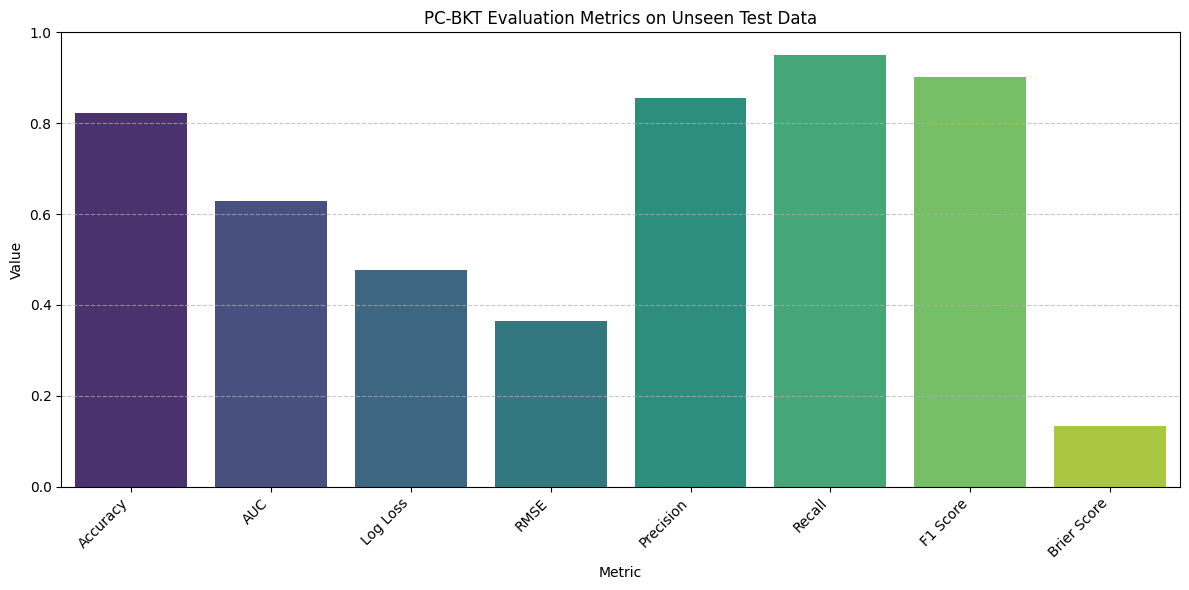

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for the metrics
metrics_data = {
    'Metric': ['Accuracy', 'AUC', 'Log Loss', 'RMSE', 'Precision', 'Recall', 'F1 Score', 'Brier Score'],
    'Value': [accuracy, auc, logloss, rmse, precision, recall, f1, brier]
}
metrics_df = pd.DataFrame(metrics_data)

# Plotting the metrics
plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')
plt.title('PC-BKT Evaluation Metrics on Unseen Test Data')
plt.ylabel('Value')
plt.ylim(0, 1) # Most metrics are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()